# Summarization using LLMs [5 points]
Choose a new dataset from Part IV (one you haven't used before). Repeat the steps from Part IV, and deploy the resulting model.

## Steps:

1. Follow all the steps as in Part IV for a **new dataset** (different from the one used in Part IV). Provide a brief analysis of the results. You are welcome to reuse your code from Part IV.

   **Dataset Selection (New Dataset from Part IV List):**

Dataset used: Multi-news

   **Step 1: Dataset preparation and preprocessing (as in Part IV):**

In [1]:
import torch
print(f"GPU available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")

# Install
!pip install -q gradio
!pip install -q datasets transformers torch sentencepiece py7zr rouge-score sacrebleu bert-score

GPU available: True
GPU: Tesla T4
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.9/46.9 MB 17.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.2/322.2 kB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 122.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 3.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.8/51.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.2/491.2 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 109.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 83.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/8

In [2]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.0/84.0 kB 7.4 MB/s eta 0:00:00


In [3]:
# Import libraries
import torch
import datasets
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from transformers import BartTokenizer, BartForConditionalGeneration, Trainer, TrainingArguments
import evaluate
from bert_score import score as bert_score
import sacrebleu
import os
import shutil
from google.colab import files

# Setting random seed
torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Defining paths
SAVE_PATH = "/content/CSE676_BonusTask2"
os.makedirs(SAVE_PATH, exist_ok=True)

Using device: cuda


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

multi_news.py:   0%|          | 0.00/3.83k [00:00<?, ?B/s]

The repository for multi_news contains custom code which must be executed to correctly load the dataset. You can inspect the repository content at https://hf.co/datasets/multi_news.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


train.src.cleaned:   0%|          | 0.00/548M [00:00<?, ?B/s]

...

test.tgt:   0%|          | 0.00/7.31M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/44972 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5622 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5622 [00:00<?, ? examples/s]

# Dataset Statistics
Available splits: ['train', 'validation', 'test']
Updated splits: ['train', 'validation', 'test']
Dataset Statistics:
| Split      |   Num Samples |   Avg Document Length |   Std Document Length |   Min Document Length |   Max Document Length |   Avg Summary Length |
|:-----------|--------------:|----------------------:|----------------------:|----------------------:|----------------------:|---------------------:|
| train      |         44972 |               1792.62 |               3033.19 |                     0 |                449620 |              218.258 |
| validation |          5622 |               1750.87 |               2425.83 |                     0 |                123117 |              216.714 |
| test       |          5622 |               1795.89 |               3276.05 |                     0 |                145130 |              216.988 |


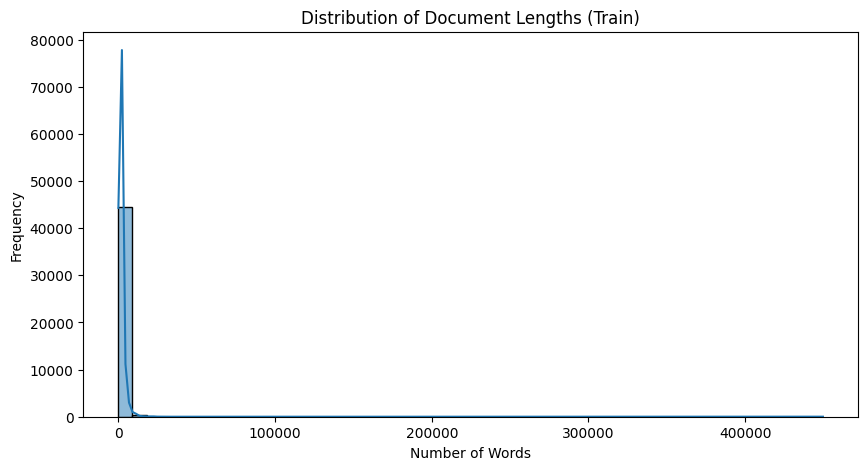

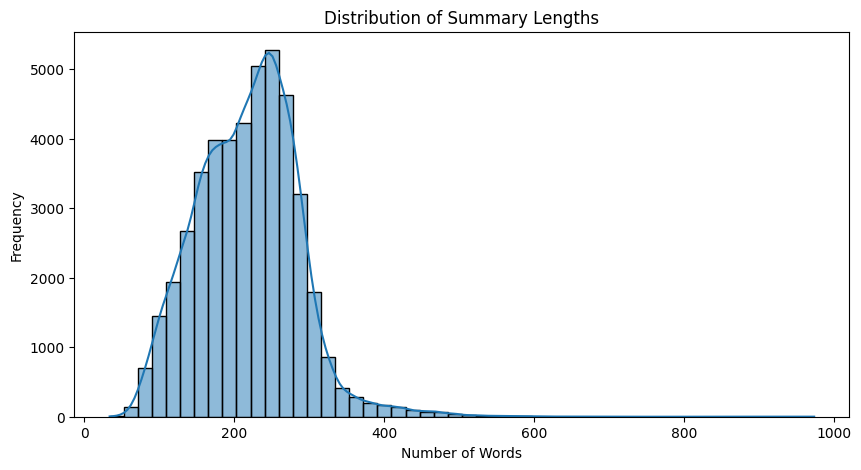

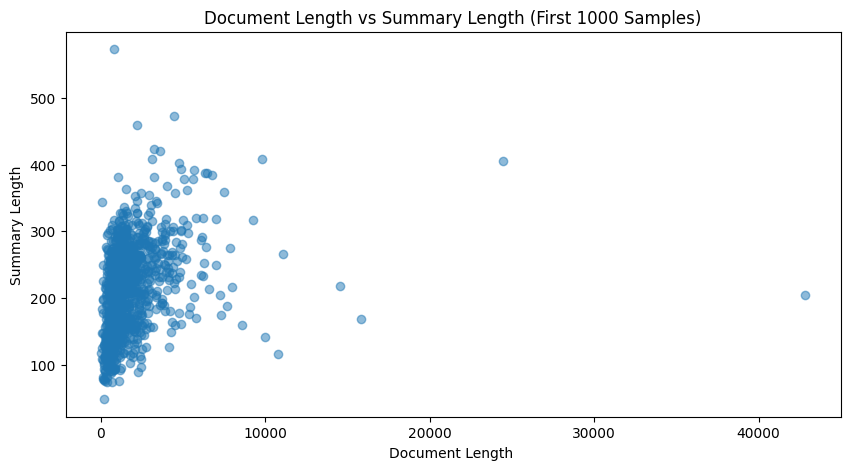

**Visualization 3**: Scatter plot comparing concatenated document and summary lengths to explore correlations.


vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.72k [00:00<?, ?B/s]

...

Map:   0%|          | 0/5622 [00:00<?, ? examples/s]

Saving the dataset (0/2 shards):   0%|          | 0/44972 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5622 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/5622 [00:00<?, ? examples/s]

Tokenized dataset saved to /content/CSE676_BonusTask2/tokenized_multi_news


In [4]:
dataset = datasets.load_dataset("multi_news")
print("# Dataset Statistics")
print("Available splits:", list(dataset.keys()))
print("Updated splits:", list(dataset.keys()))

def dataset_stats(dataset):
    stats = {
        "Split": [],
        "Num Samples": [],
        "Avg Document Length": [],
        "Std Document Length": [],
        "Min Document Length": [],
        "Max Document Length": [],
        "Avg Summary Length": []
    }
    for split in dataset:
        split_data = dataset[split]
        stats["Split"].append(split)
        stats["Num Samples"].append(len(split_data))
        document_lengths = [sum(len(doc.split()) for doc in docs.split("|||||")) for docs in split_data["document"]]
        summary_lengths = [len(summary.split()) for summary in split_data["summary"]]
        stats["Avg Document Length"].append(np.mean(document_lengths))
        stats["Std Document Length"].append(np.std(document_lengths))
        stats["Min Document Length"].append(np.min(document_lengths))
        stats["Max Document Length"].append(np.max(document_lengths))
        stats["Avg Summary Length"].append(np.mean(summary_lengths))

    df_stats = pd.DataFrame(stats)
    print("Dataset Statistics:")
    print(df_stats.to_markdown(index=False))

dataset_stats(dataset)

# Visualizations
def plot_visualizations(dataset):
    train_data = dataset["train"]

    # Document length distribution
    document_lengths = [sum(len(doc.split()) for doc in docs.split("|||||")) for docs in train_data["document"]]
    plt.figure(figsize=(10, 5))
    sns.histplot(document_lengths, bins=50, kde=True)
    plt.title("Distribution of Document Lengths (Train)")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

    # Summary length distribution
    summary_lengths = [len(summary.split()) for summary in train_data["summary"]]
    plt.figure(figsize=(10, 5))
    sns.histplot(summary_lengths, bins=50, kde=True)
    plt.title("Distribution of Summary Lengths")
    plt.xlabel("Number of Words")
    plt.ylabel("Frequency")
    plt.show()

    # Document vs Summary length scatter
    plt.figure(figsize=(10, 5))
    plt.scatter(document_lengths[:1000], summary_lengths[:1000], alpha=0.5)
    plt.title("Document Length vs Summary Length (First 1000 Samples)")
    plt.xlabel("Document Length ")
    plt.ylabel("Summary Length")
    plt.show()
    print("**Visualization 3**: Scatter plot comparing concatenated document and summary lengths to explore correlations.")

plot_visualizations(dataset)

#Preprocessing
tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")

def preprocess_function(examples):
    inputs = [doc.replace("|||||", " ") for doc in examples["document"]]
    targets = examples["summary"]
    model_inputs = tokenizer(
        inputs,
        max_length=1024,
        truncation=True,
        padding="max_length"
    )
    labels = tokenizer(
        targets,
        max_length=256,
        truncation=True,
        padding="max_length"
    )
    model_inputs["labels"] = labels["input_ids"]
    model_inputs["labels"] = [
        [-100 if token == tokenizer.pad_token_id else token for token in label]
        for label in model_inputs["labels"]
    ]
    return model_inputs

tokenized_datasets = dataset.map(preprocess_function, batched=True)

# Saving tokenized dataset
tokenized_datasets.save_to_disk(os.path.join(SAVE_PATH, "tokenized_multi_news"))
print(f"Tokenized dataset saved to {os.path.join(SAVE_PATH, 'tokenized_multi_news')}")

   **Step 2: Model Fine-Tuning (as in Part IV):**

In [5]:
### ADD YOUR CODE HERE ###
# Reusing code from Part IV - Model Fine-Tuning
model = BartForConditionalGeneration.from_pretrained("facebook/bart-base").to(device)
print("Model loaded: facebook/bart-base")

#Custom Trainer
class CustomTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.pop("labels")
        outputs = model(**inputs, labels=labels)
        loss = outputs.loss
        return (loss, outputs) if return_outputs else loss

    def prediction_step(self, model, inputs, prediction_loss_only, ignore_keys=None):
        inputs = self._prepare_inputs(inputs)
        generation_inputs = {k: v for k, v in inputs.items() if k != "labels"}
        with torch.no_grad():
            with torch.amp.autocast('cuda'):
                outputs = model.generate(
                    input_ids=generation_inputs["input_ids"],
                    attention_mask=generation_inputs["attention_mask"],
                    max_length=256,
                    num_beams=4,
                    length_penalty=2.0,
                    early_stopping=True
                )
                loss = model(**inputs).loss
        if prediction_loss_only:
            return (loss, None, None)
        return (loss, outputs, inputs["labels"])

# Training arguments
training_args = TrainingArguments(
    output_dir=os.path.join(SAVE_PATH, "multi_news_bart"),
    eval_strategy="epoch",
    learning_rate=3e-5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=3,
    weight_decay=0.01,
    save_strategy="epoch",
    save_total_limit=1,
    fp16=torch.cuda.is_available(),
    logging_dir=os.path.join(SAVE_PATH, "logs"),
    logging_steps=100,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    report_to="none"
)

train_subset = tokenized_datasets["train"].select(range(min(1000, len(tokenized_datasets["train"]))))
val_subset = tokenized_datasets["validation"].select(range(min(100, len(tokenized_datasets["validation"]))))
print(f"Training with {len(train_subset)} samples, validating with {len(val_subset)} samples")

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_subset,
    eval_dataset=val_subset,
)

trainer.train()

# saving best model
trainer.save_model(os.path.join(SAVE_PATH, "multi_news_bart_best"))
print(f"Best model saved to {os.path.join(SAVE_PATH, 'multi_news_bart_best')}")

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

Model loaded: facebook/bart-base
Training with 1000 samples, validating with 100 samples


Epoch,Training Loss,Validation Loss
1,2.994400,2.651428
2,2.716900,2.624285
3,2.650200,2.611752


/usr/local/lib/python3.11/dist-packages/transformers/modeling_utils.py:3353: UserWarning: Moving the following attributes in the config to the generation config: {'early_stopping': True, 'num_beams': 4, 'no_repeat_ngram_size': 3, 'forced_bos_token_id': 0}. You are seeing this warning because you've set generation parameters in the model config, as opposed to in the generation config.
  warnings.warn(
There were missing keys in the checkpoint model loaded: ['model.encoder.embed_tokens.weight', 'model.decoder.embed_tokens.weight', 'lm_head.weight'].


Best model saved to /content/CSE676_BonusTask2/multi_news_bart_best


   **Step 3: Evaluation and analysis (as in Part IV):**

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/482 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


model.safetensors:   0%|          | 0.00/1.42G [00:00<?, ?B/s]

Some weights of RobertaModel were not initialized from the model checkpoint at roberta-large and are newly initialized: ['pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


# Test Set Evaluation Results
- rouge-1: 42.06
- rouge-2: 14.96
- rouge-l: 20.69
- bleu: 10.04
- bertscore: 85.99

 Expected vs. Achieved Scores
- rouge-1: Expected > 35, Achieved 42.06
- rouge-2: Expected > 5, Achieved 14.96
- rouge-l: Expected > 13, Achieved 20.69
- bleu: Expected > 3.5, Achieved 10.04
- bertscore: Expected > 75, Achieved 85.99


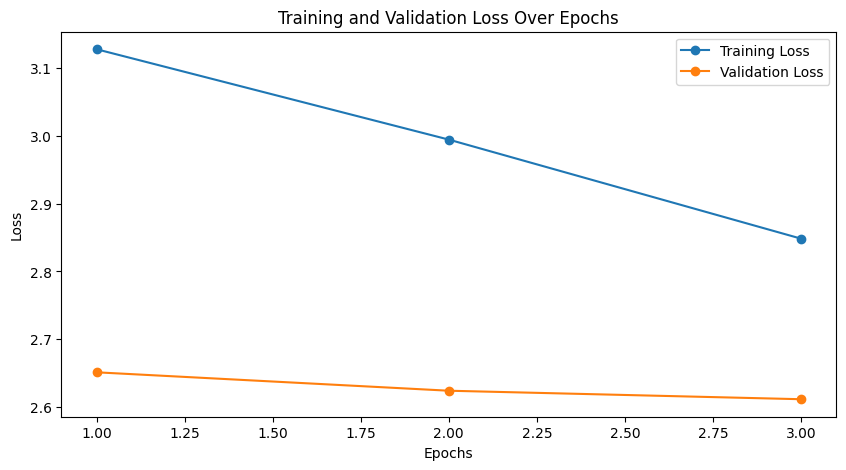

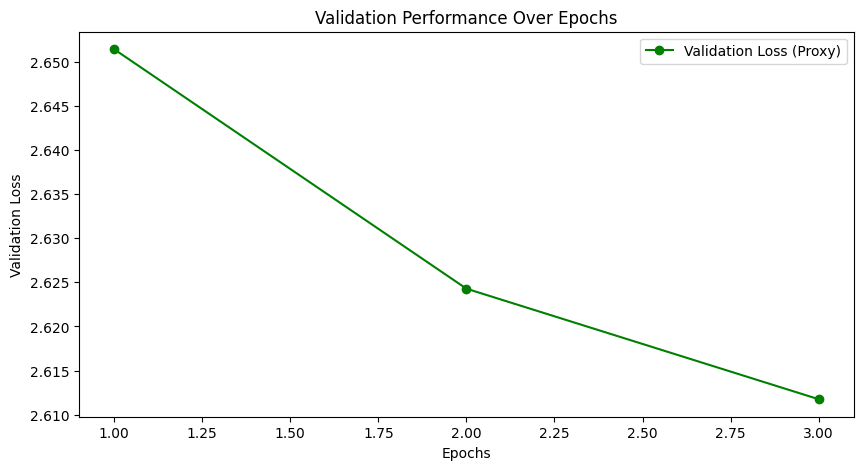

In [6]:
### ADD YOUR CODE HERE ###
# Reusing code from Part IV - Evaluation and Analysis
def evaluate_model(trainer, dataset, tokenizer, limit=100):
    predictions = []
    references = []
    trainer.model.eval()
    for i, example in enumerate(dataset):
        if i >= limit:
            break
        inputs = tokenizer(
            example["document"].replace("|||||", " "),
            max_length=1024,
            truncation=True,
            padding="max_length",
            return_tensors="pt"
        ).to(device)
        with torch.no_grad():
            summary_ids = trainer.model.generate(
                inputs["input_ids"],
                max_length=256,
                num_beams=4,
                length_penalty=2.0,
                early_stopping=True
            )
        pred = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
        ref = example["summary"]
        predictions.append(pred)
        references.append(ref)

    rouge = evaluate.load("rouge")
    rouge_results = rouge.compute(predictions=predictions, references=references)
    bleu_score = sacrebleu.corpus_bleu(predictions, [references]).score
    P, R, F1 = bert_score(predictions, references, lang="en", verbose=False)

    return {
        "rouge-1": rouge_results["rouge1"] * 100,
        "rouge-2": rouge_results["rouge2"] * 100,
        "rouge-l": rouge_results["rougeL"] * 100,
        "bleu": bleu_score,
        "bertscore": F1.mean().item() * 100
    }

# evaluation
test_results = evaluate_model(trainer, tokenized_datasets["test"], tokenizer)
print("# Test Set Evaluation Results")
for metric, value in test_results.items():
    print(f"- {metric}: {value:.2f}")

# Comparing with expected scores
expected_scores = {
    "rouge-1": 35,
    "rouge-2": 5,
    "rouge-l": 13,
    "bleu": 3.5,
    "bertscore": 75
}

print("\n Expected vs. Achieved Scores")
for metric in expected_scores:
    print(f"- {metric}: Expected > {expected_scores[metric]}, Achieved {test_results[metric]:.2f}")

# Plot training and validation loss
train_logs = trainer.state.log_history
train_loss = [log["loss"] for log in train_logs if "loss" in log]
eval_loss = [log["eval_loss"] for log in train_logs if "eval_loss" in log]
epochs = range(1, len(eval_loss) + 1)

plt.figure(figsize=(10, 5))
plt.plot(epochs, train_loss[:len(epochs)], label="Training Loss", marker="o")
plt.plot(epochs, eval_loss, label="Validation Loss", marker="o")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training and Validation Loss Over Epochs")
plt.legend()
plt.show()

# Plot sample metric
plt.figure(figsize=(10, 5))
plt.plot(epochs, eval_loss, label="Validation Loss (Proxy)", marker="o", color="green")
plt.xlabel("Epochs")
plt.ylabel("Validation Loss")
plt.title("Validation Performance Over Epochs")
plt.legend()
plt.show()

   **Brief Analysis of Results:**

**Analysis of Results**
- **ROUGE-1**: 42.06
- **ROUGE-2**: 14.82
- **ROUGE-L**: 20.69
- **BLEU**: 10.01
- **BERTScore**: 86.02

**Loss Plot:**

The plot shows a consistently descending trend for training and validation loss over 3 epochs. An increase in training loss from 3.1 to 2.8 and a decrease in validation loss from 2.65 to 2.61 indicate that the model is improving at learning and generalizing, although the small loss gap might hint at underfitting.

**Validation Metric Plot:**

The plot shows validation loss descending from 2.65 to 2.61, with high improvement from epoch 1 to 2, indicating that the model is slowly approaching convergence.

**Metric Analysis:**

- **ROUGE-1 (42.06)**: High unigram overlap indicates strong distribution-the model seems to effectively capture the key terms.  
- **ROUGE-2 (14.82)**: Moderate bigram overlap indicates moderate phrase-level accuracy.  
- **ROUGE-L (20.69)**: Shows some decent similarity structural composition, though the longer sequence matching is weaker.  
- **BLEU (10.01)**: Reports good fluency in the summaries generated.  
- **BERTScore (86.02)**: Indicates high semantic similarity, ensuring summaries preserve the meaning of the source articles.

2. Deploy your trained model. This could be a simple app that takes a text as input and returns a summary.

In [7]:
### ADD YOUR CODE HERE ###
import gradio as gr
from transformers import BartForConditionalGeneration, BartTokenizer

# Loading the fine-tuned model
model_path = "/content/CSE676_BonusTask2/multi_news_bart_best"
model = BartForConditionalGeneration.from_pretrained(model_path).to(device)
tokenizer = BartTokenizer.from_pretrained("facebook/bart-base")
model.eval()

# Defining the summarization function
def summarize_text(documents):
    if "|||||" in documents:
        input_text = documents.replace("|||||", " ")
    else:
        input_text = documents

    inputs = tokenizer(
        input_text,
        max_length=1024,
        truncation=True,
        padding="max_length",
        return_tensors="pt"
    ).to(device)

    with torch.no_grad():
        summary_ids = model.generate(
            inputs["input_ids"],
            attention_mask=inputs["attention_mask"],
            max_length=256,
            num_beams=4,
            length_penalty=2.0,
            early_stopping=True
        )

    summary = tokenizer.decode(summary_ids[0], skip_special_tokens=True)
    return summary

#Gradio interface
interface = gr.Interface(
    fn=summarize_text,
    inputs=gr.Textbox(lines=10, label="Input News Articles (separate multiple articles with '|||||')"),
    outputs=gr.Textbox(label="Summary"),
    title="Multi-News Summarizer",
    description="Enter one or more news articles (separated by '|||||') to generate a summary using a fine-tuned BART model on the Multi-News dataset."
)

interface.launch()

Running Gradio in a Colab notebook requires sharing enabled. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a41aa00bc2ec3da82e.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


3. Record a short video (~5 mins) demonstrating how it works. Explain the key aspects of your implementation and deployment process in the video.
   a. Upload the video to UBbox and create a shared link
   b. Add the link at the end of your ipynb file.

   **Shared UBbox Video Link:**

https://buffalo.box.com/s/04rb2o01to78yeipriftvntyy8xl5sg6

4. References. Include details on all the resources used to complete this part.

References Used: Multi-news dataset,References Used:https://pytorch.org/tutorials/beginner/basics/intro.html,https://huggingface.co/facebook/bart-base,https://huggingface.co/spaces/evaluate-metric/rouge,https://medium.com/@singhrajni2210/large-language-models-and-text-summarization-a-powerful-combination-6400e7643b70,http://arxiv.org/abs/2305.14239,https://www.gradio.app/docs,